In [ ]:
# prefix node reward assignment

let me think               A*=+0.58  ΣA=-0.00 (mean -0.00)  cnt=4  correct=3
  step                       A*=+0.58  ΣA=-0.58 (mean -0.19)  cnt=3  correct=2
    A then 42                  A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1
    B then                     A*=+0.58  ΣA=-1.15 (mean -0.58)  cnt=2  correct=1
      17                         A*=-1.73  ΣA=-1.73 (mean -1.73)  cnt=1  correct=0
      17, but wait it should be 42 A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1
  harder C then 9            A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1


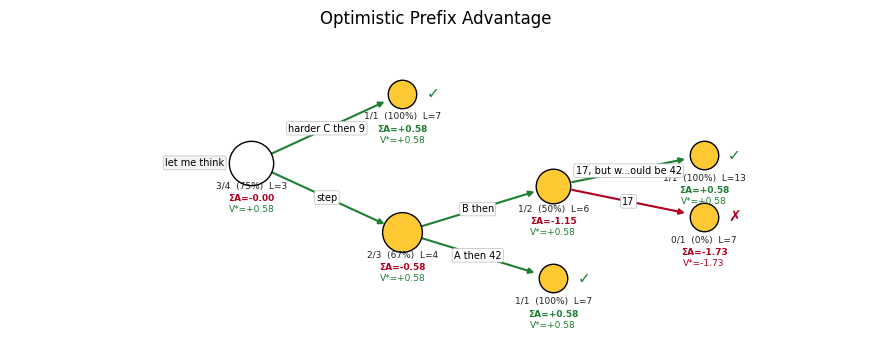

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("/Users/fangyuanyu/Implementation/arl")))
import src.prefix_trie as pt
importlib.reload(pt)   # pick up changes without restarting the kernel

# ---------------------------------------------------------------------------
# Convention (per request):
#   (1) REWARD is the hard-coded scalar per rollout. Here it's the plain
#       correctness reward, so every CORRECT rollout shares reward = 1.0.
#   (2) ADVANTAGE is computed EXACTLY, GRPO-style, over the group:
#         a_i = (r_i - mean(r)) / (std(r) + eps)
#   (3) V*(node) = max ADVANTAGE over rollouts through the node (optimistic
#       backup over the per-trajectory advantage).
# ---------------------------------------------------------------------------
EPS = 1e-8

rollouts = [
    ("let me think step A then 42".split(),   True),   # correct
    ("let me think step B then 17".split(),   False),  # wrong
    ("let me think step B then 17, but wait it should be 42".split(),   True),  # correct
    ("let me think harder C  then 9".split(), True),  # wrong
]
correct = np.array([c for _, c in rollouts], dtype=float)
reward  = correct.copy()                      # hard-coded reward = correctness

# (1)+(2): exact GRPO advantage over the group.
mean_r = reward.mean()
std_r  = reward.std()                          # population std (ddof=0)
advantage = (reward - mean_r) / (std_r + EPS)  # per-trajectory advantage

tbl = pd.DataFrame({
    "rollout":   [" ".join(t) for t, _ in rollouts],
    "correct":   correct.astype(bool),
    "reward":    reward,
    "advantage": advantage.round(4),
})

# (3): build the trie with the advantage as the per-rollout value.
# `build_trie_with_correctness` feeds `advantage` to BOTH ΣA and V* (= max adv).
rows = [(toks, bool(c), float(a))
        for (toks, c), a in zip(rollouts, advantage)]
trie = pt.build_trie_with_correctness(rows)
tree = pt._collapse(trie.root)

def show(node, depth=0):
    seg = " ".join(node["tokens"]) or "(root)"
    adv_mean = node["adv_sum"] / node["adv_n"] if node["adv_n"] else float("nan")
    print(f"{'  '*depth}{seg:<26s} A*={node['v_star']:+.2f}  "
          f"ΣA={node['adv_sum']:+.2f} (mean {adv_mean:+.2f})  "
          f"cnt={node['count']}  correct={node['count_correct']}")
    for ch in node["children"].values():
        show(ch, depth + 1)

# print("Optimistic Prefix Advantage")
show(tree)


fig, ax = plt.subplots(figsize=(11, 4))
pt.draw_compressed_trie(ax, trie)
ax.set_title("Optimistic Prefix Advantage")
plt.show()


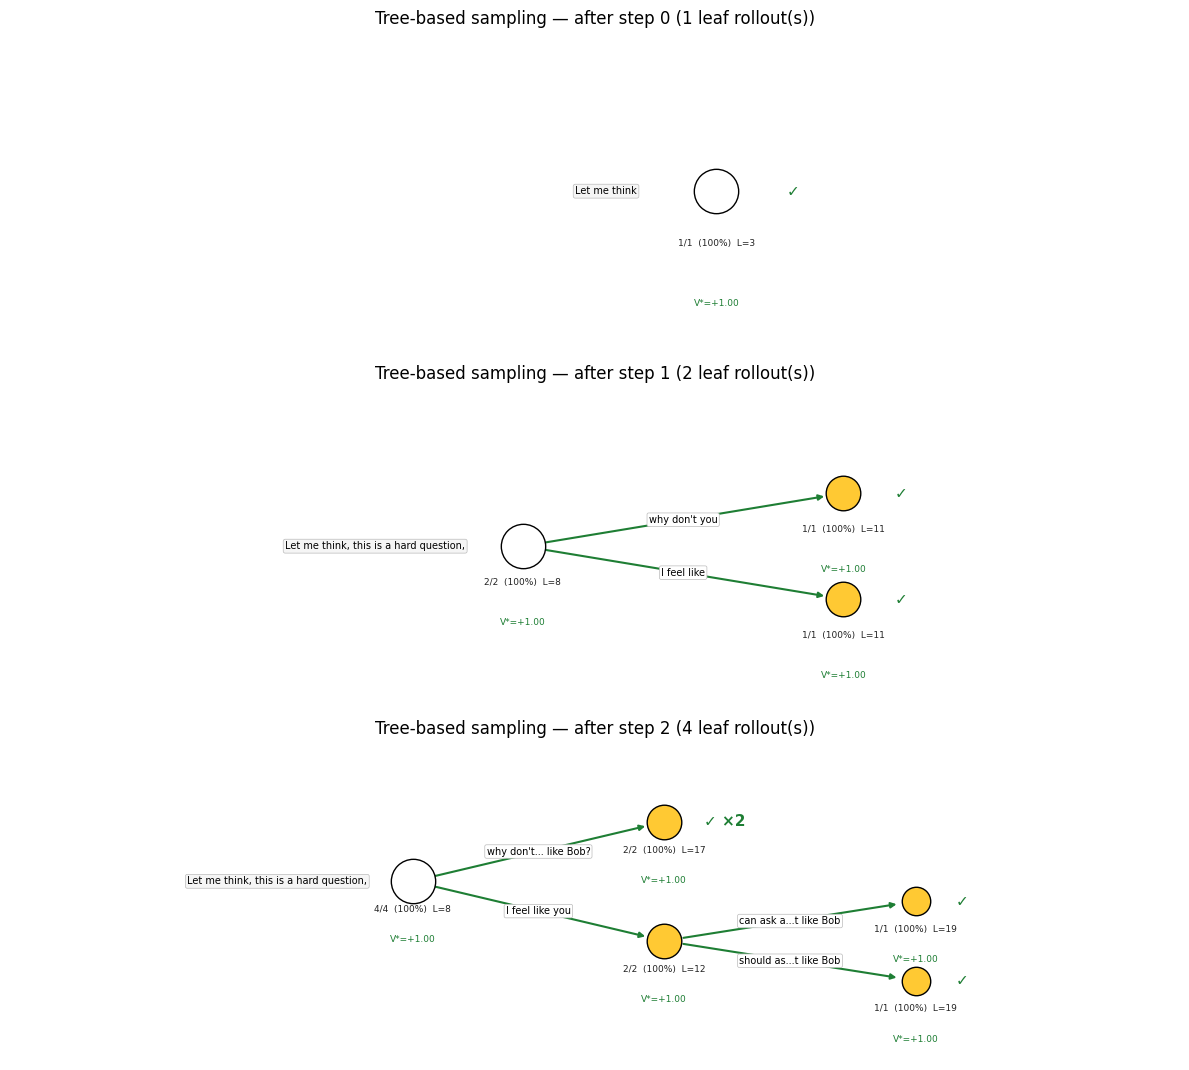

In [2]:
# Tree Based Sampling
# Given a query, generate 2 rollouts with 10 new tokens
#                add to prefix trie, on all leaf node (can be one or two, depending on whether 2 rollouts differ)
#                generate 2 rollouts on each leaf node with 10 new tokens, extend prefix trie

# implement the "add to trie" method, and help me visualize 'draw_compressed_trie'
# on each steps using examples below

# step 0
r0 = "Let me think"

# step 1
r00 = ", this is a hard question, I feel like"
r01 = ", this is a hard question, why don't you"

# step 2
r000 = " you should ask a good student like Bob"
r001 = " you can ask a good student like Bob"
r010 = " ask a good student like Bob?"
r011 = " ask a good student like Bob?"

# ---------------------------------------------------------------------------
# Tree-sampling bookkeeping
#   - SEG[node] = the ~10 fresh tokens generated AT that node.
#   - STEPS[k]  = the set of active leaf rollouts (root->leaf node paths)
#                 after sampling step k. Each leaf spawns 2 children next step;
#                 identical children (r010 == r011) collapse to one trie leaf.
# ---------------------------------------------------------------------------
SEG = {
    "r0":   r0,
    "r00":  r00,  "r01":  r01,
    "r000": r000, "r001": r001, "r010": r010, "r011": r011,
}
STEPS = {
    0: [["r0"]],
    1: [["r0", "r00"], ["r0", "r01"]],
    2: [["r0", "r00", "r000"], ["r0", "r00", "r001"],
        ["r0", "r01", "r010"], ["r0", "r01", "r011"]],
}


def path_tokens(path):
    """Full root->leaf token list for a leaf `path` (list of node keys).

    Literal string concatenation (no injected separators), then the same
    whitespace split `pt.tokenize` uses — so the trie reflects exactly what
    the model emitted and shared prefixes merge correctly.
    """
    return pt.tokenize("".join(SEG[k] for k in path))


def add_to_trie(trie, leaf_paths, correct=True):
    """The "add to trie" step: insert every current leaf rollout (root->leaf)
    into the prefix trie. Shared prefixes merge, divergences fork. Rebuilding
    from the current leaf set after each sampling round is equivalent to
    extending in place, but keeps the pass-through counts exact (count at a
    node == number of current leaves in its subtree).
    """
    for path in leaf_paths:
        trie.insert(path_tokens(path), correct=correct)
    return trie


# --- visualize draw_compressed_trie after each sampling step ----------------
fig, axes = plt.subplots(len(STEPS), 1, figsize=(12, 3.6 * len(STEPS)))
axes = np.atleast_1d(axes)
for step, ax in zip(sorted(STEPS), axes):
    trie = pt.Trie()
    add_to_trie(trie, STEPS[step])
    pt.draw_compressed_trie(ax, trie)
    ax.set_title(f"Tree-based sampling — after step {step} "
                 f"({len(STEPS[step])} leaf rollout(s))")
plt.tight_layout()
plt.show()


In [3]:
# Now we need to wire to a .generate function, we can use locally a Qwen3-0.6B model first
# (1). model generate according to our tree based sampling logic 
# (2). we assign OPA advantage / GRPO advantage on them
# (3). visualize each step

In [3]:
# (1) Tree-based sampling with a real model (Qwen3-0.6B, run locally).
#     Same logic as the toy cell above: each current leaf spawns `branch`
#     continuations of `block_size` tokens; identical continuations collapse,
#     so a leaf forks into 1..branch children.
#     NOTE: `block_size` is the per-step extension length. Set it equal to the
#     vLLM KV `block_size` (commonly 16) so prefix-cache reuse lands on block
#     boundaries — same number on purpose.
#     TERMINATION: a continuation that emits <eos> is truncated at the first
#     <eos> and its leaf is marked `done`; done leaves are carried forward as-is
#     (never re-expanded), so we don't dumbly generate past end-of-sequence.
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen3-0.6B"
DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
gen_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=(torch.float32 if DEVICE == "cpu" else torch.float16),
).to(DEVICE).eval()
EOS_ID = tokenizer.eos_token_id
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else EOS_ID
print(f"loaded {MODEL_NAME} on {DEVICE}")


@torch.no_grad()
def _continue(prefix_ids, block_size, n_samples, temperature):
    """Sample `n_samples` continuations of up to `block_size` tokens from a 1-D
    prefix. Returns a list of (cont_tokens, done) pairs; a continuation that
    hits <eos> is truncated to include that <eos> and flagged done."""
    batch = prefix_ids.unsqueeze(0).repeat(n_samples, 1).to(DEVICE)
    out = gen_model.generate(
        batch, max_new_tokens=block_size, do_sample=True,
        temperature=temperature, pad_token_id=PAD_ID, eos_token_id=EOS_ID,
    )
    new = out[:, prefix_ids.shape[0]:]                 # (n_samples, <=block_size)
    results = []
    for row in new.tolist():
        if EOS_ID in row:                              # truncate at first <eos>
            row = row[: row.index(EOS_ID) + 1]
            done = True
        else:
            done = False
        results.append((row, done))
    return results


def tree_sample(prompt, n_steps=3, block_size=8, branch=2,
                temperature=1.0, seed=0):
    """Breadth-first tree sampling. Returns (prompt_ids, steps) where
    steps[k] is the list of leaf continuations (token-id lists, EXCLUDING the
    prompt) present after sampling step k. Leaves that have emitted <eos> are
    carried forward unchanged rather than re-expanded."""
    torch.manual_seed(seed)
    prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids[0]
    leaves = [([], False)]                             # (continuation_so_far, done)
    steps = {}
    for step in range(n_steps):
        nxt, seen = [], set()
        for leaf, done in leaves:
            if done:                                   # terminated: carry forward, don't regenerate
                key = tuple(leaf)
                if key not in seen:
                    seen.add(key); nxt.append((leaf, True))
                continue
            prefix = torch.cat([prompt_ids, torch.tensor(leaf, dtype=torch.long)])
            for cont, cont_done in _continue(prefix, block_size, branch, temperature):
                child = leaf + cont
                key = tuple(child)
                if key not in seen:                    # dedup identical continuations
                    seen.add(key); nxt.append((child, cont_done))
        leaves = nxt
        steps[step] = [list(l) for l, _ in leaves]
    return prompt_ids, steps


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

loaded Qwen/Qwen3-0.6B on mps


In [ ]:
# (2) Assign GRPO scalar advantage + OPA per-token advantage on the FINAL
#     leaves (the complete rollouts). Earlier steps are structural only.
import src.tree_trainer as tt
importlib.reload(tt)

PROMPT = "Fibonacci sequence: 1 2 3 "
prompt_ids, steps = tree_sample(PROMPT, n_steps=7, block_size=4, branch=2,
                                temperature=1.0, seed=0)

final = steps[max(steps)]                              # complete rollouts (token-id lists)
texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in final]


# --- reward: PLACEHOLDER. Swap for real task correctness. -------------------
# A toy signal that varies across leaves (so the group isn't degenerate):
# the number of digit characters the rollout emitted.
def reward_fn(text):
    return float(sum(ch.isdigit() for ch in text))


reward = np.array([reward_fn(t) for t in texts], dtype=float)

# GRPO group advantage  a_i = (r_i - mean) / (std + eps).
adv = (reward - reward.mean()) / (reward.std() + EPS)

# OPA per-token A* over the group, keyed on the REAL token ids (exact).
per_token, opa_trie = tt.optimistic_prefix_advantages(
    final, adv.tolist(), return_trie=True,
)

for t, r, a in zip(texts, reward, adv):
    print(f"r={r:5.1f}  a={a:+.2f} | {t!r}")
print(f"\nshared-prefix token fraction (final trie): "
      f"{opa_trie.shared_prefix_token_fraction:.1%}")
print(f"breakdown: {opa_trie.token_node_breakdown()}")


r=  6.0  a=+1.02 | '5 8 13 ...\nGiven that 1 and 2 are the first two terms, and each subsequent term is the sum of'
r=  7.0  a=+1.83 | '5 8 13 ...\nGiven that 1 and 2 are the first two terms, and the third term is 3,'
r=  4.0  a=-0.62 | '5 8 13 ...\nGiven a recursive formula with Fibonacci numbers, how can we find a closed-form formula?\nLet’s assume that'
r=  4.0  a=-0.62 | '5 8 13 ...\nGiven a recursive formula with Fibonacci numbers, how can we find a closed-form formula?\nThe answer is that'
r=  4.0  a=-0.62 | '5 8 13 ...\nGiven a recursive formula with Fibonacci numbers, how can we find a closed-form formula?\n\nIn the previous problem'
r=  4.0  a=-0.62 | '5 8 13 ...\nGiven a recursive formula with Fibonacci numbers, how can we find a closed-form formula?\n\nI am a student'
r=  4.0  a=-0.62 | '5 8 13 ...\nGiven a recursive formula with Fibonacci numbers, how can I compute their values in the correct sequence?\n\nI know'
r=  4.0  a=-0.62 | '5 8 13 ...\nGiven a recursive formula wit

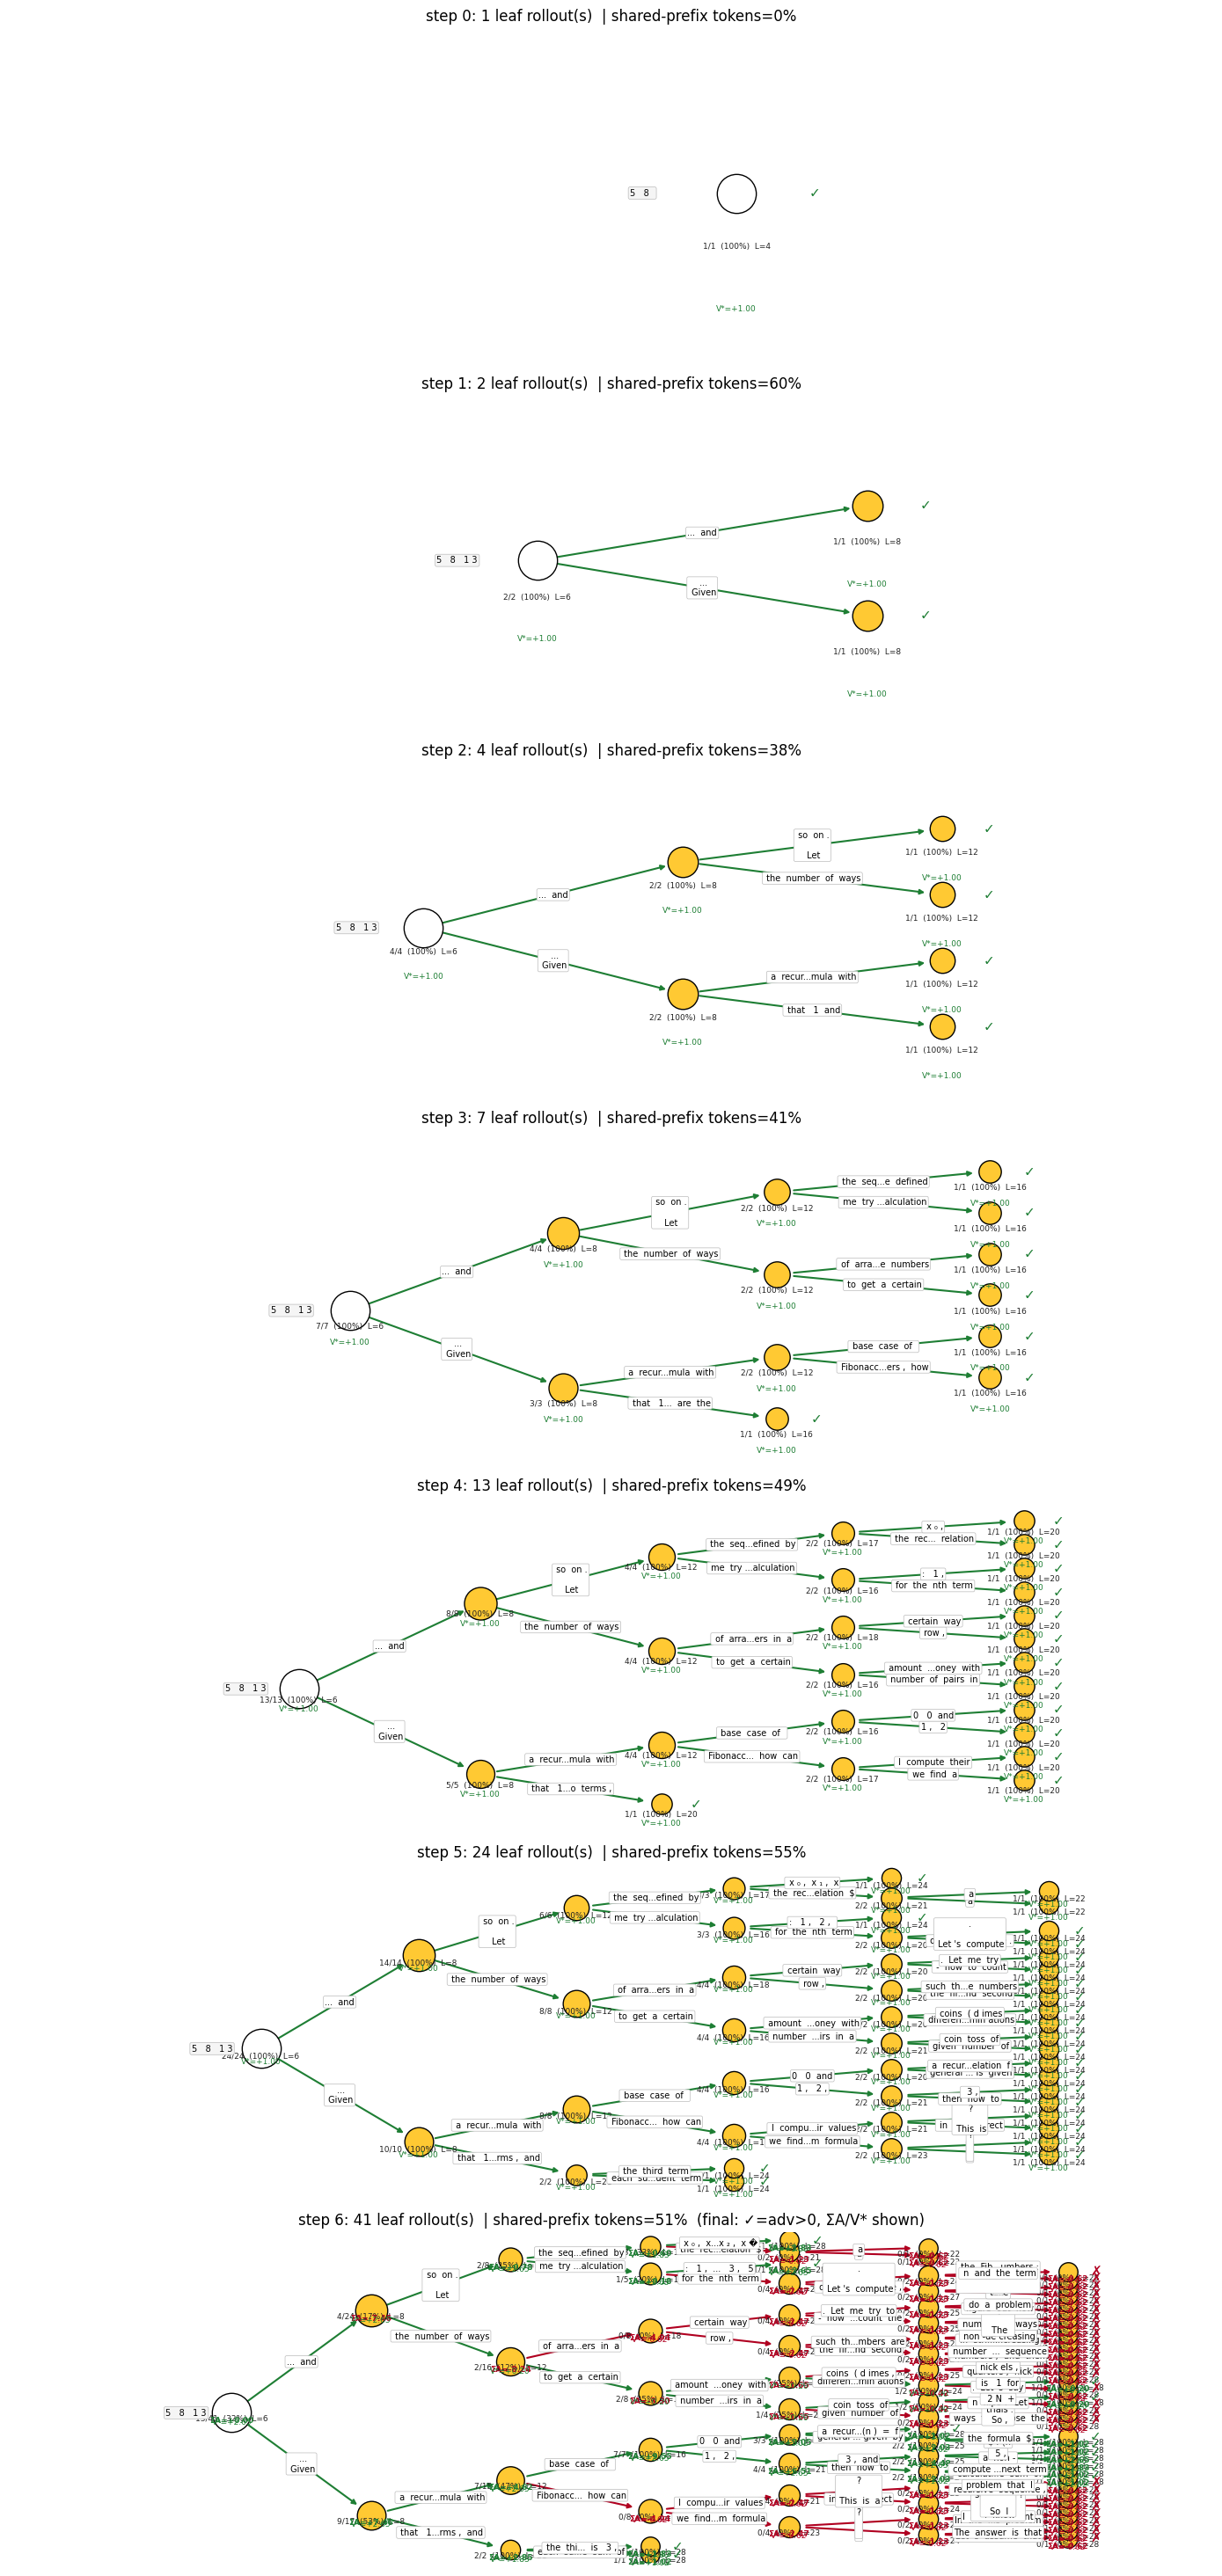

In [35]:
# (3) Visualize the tree after each sampling step (real tokens).
#     The viz pt.Trie is keyed on PER-TOKEN decoded strings so it forks exactly
#     where token ids diverge (decoding the full text then whitespace-splitting
#     would shift the fork points). Only the FINAL step carries reward/advantage.

def decode_tokens(ids):
    return [tokenizer.decode([i]) for i in ids]

adv_of = {tuple(ids): a for ids, a in zip(final, adv.tolist())}   # last-panel labels

n_steps = len(steps)
fig, axes = plt.subplots(n_steps, 1, figsize=(14, 4.2 * n_steps))
axes = np.atleast_1d(axes)
for step, ax in zip(sorted(steps), axes):
    is_last = (step == max(steps))
    vt = pt.Trie()
    for ids in steps[step]:
        toks = decode_tokens(ids)
        if is_last:
            a = adv_of.get(tuple(ids), 0.0)
            vt.insert(toks, correct=(a > 0), advantage=a)   # ΣA / V* shown on last panel
        else:
            vt.insert(toks, correct=True)
    pt.draw_compressed_trie(ax, vt)
    extra = "  (final: ✓=adv>0, ΣA/V* shown)" if is_last else ""
    ax.set_title(f"step {step}: {len(steps[step])} leaf rollout(s)  | "
                 f"shared-prefix tokens={vt.shared_prefix_token_fraction:.0%}{extra}")
plt.tight_layout()
plt.show()


In [43]:
# (4) Export the tree rollout to JSON for the interactive viewer
#     (tree_rollout_app.html -> "load JSON"). Tokens are the SAME per-token
#     decoded strings the matplotlib viz uses, so forks line up exactly.
import json

last = max(steps)
export = {
    "prompt": PROMPT,
    "block_size": 4,                                   # match tree_sample(block_size=...)
    "steps": [[decode_tokens(ids) for ids in steps[s]] for s in sorted(steps)],
    "finalAdv": [float(adv_of.get(tuple(ids), 0.0)) for ids in steps[last]],
}
out_path = Path("/Users/fangyuanyu/Implementation/arl/tree_rollout_data.json")
out_path.write_text(json.dumps(export))
print(f"wrote {out_path}  ({len(export['steps'])} steps, "
      f"{len(export['steps'][-1])} final leaves)")


wrote /Users/fangyuanyu/Implementation/arl/tree_rollout_data.json  (7 steps, 41 final leaves)
